# EDA sobre partición de train - Fraud Dataset

Este notebook se realiza un analisis exploratorio mas detallado ademas de particioanr la informacion de la siguiente forma:

1. El dataset de train corresponde. alos primeros 30 días y el dataset de test a los 14 días restantes
2. Se realiza un análisis solo para la partición de Train para los siguientes aspectos generales:
   - Correlación y multicolinealidad entre variables numéricas y el target.
   - Sesgo (skewness) y outliers en variables numéricas.
   - Utilidad de las variables categóricas para detectar fraude (asociación con el target).

# Imports

In [20]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import numpy as np
import statsmodels.api as sm


ROOT_DIR = Path.cwd().parent if (Path.cwd().name == "01_EDA") else Path.cwd()
sys.path.insert(0, str(ROOT_DIR))

from src.utils.eda import EDA
from src.models.model_utils import train_test_split_time
from src.utils.graphics_utils import plot_numeric_grid_by_target

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Configs

In [21]:
FULL_DATA_PATH = ROOT_DIR / "dataset" / "MercadoLibre Data Scientist Hiring Test - Fraud Dataset with date v2.csv"
DATASET_DIR = ROOT_DIR / "dataset"
TRAIN_PATH = DATASET_DIR / "train.csv"
TEST_PATH = DATASET_DIR / "test.csv"

OUTPUT_DIR = ROOT_DIR / "01_EDA"
TABLES_DIR = OUTPUT_DIR / "tables_train"
FIGURES_DIR = OUTPUT_DIR / "figures_train"
TARGET_COL = "fraude"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FULL_DATA_PATH

PosixPath('/Users/dpiedrahita/proyectos/DS_pro/dataset/MercadoLibre Data Scientist Hiring Test - Fraud Dataset with date v2.csv')

# Read Data

In [22]:
eda_full = EDA(FULL_DATA_PATH)
df_full = eda_full.load()
print(f"Shape total: {df_full.shape}")
df_full.head()

Shape total: (150000, 19)


,a,b,c,d,e,f,g,h,j,k,l,m,n,o,p,fecha,monto,score,fraude
0,4,0.6812,50084.12,50.0,0.000000,20.0,AR,1,cat_d26ab52,0.365475,2479.0,952.0,1,NaN,Y,2020-03-20 09:28:19,57.63,100,0
1,4,0.6694,66005.49,0.0,0.000000,2.0,AR,1,cat_ea962fb,0.612728,2603.0,105.0,1,Y,Y,2020-03-09 13:58:28,40.19,25,0
2,4,0.4718,7059.05,4.0,0.463488,92.0,BR,25,cat_4c2544e,0.651835,2153.0,249.0,1,Y,Y,2020-04-08 12:25:55,5.77,23,0
3,4,0.7260,10043.10,24.0,0.046845,43.0,BR,43,cat_1b59ee3,0.692728,4845.0,141.0,1,N,Y,2020-03-14 11:46:13,40.89,23,0
4,4,0.7758,16584.42,2.0,0.154616,54.0,BR,0,cat_9bacaa5,0.201354,2856.0,18.0,1,Y,N,2020-03-23 14:17:13,18.98,71,0


## 1. Split train / test por fecha

A continuación, se reazliza el split del dataset de Train y test, mediante split temporal, esta es uan tecnica muy utilizada en detección de Fraude, en lugar de utiulizar splits tradicionales con métodos random, esto garantiza si un futuro modelo es capaz de detectar el fraude reciente, cuando se utiliza splits random, los modelos peuden caer en aprender a dtectar fraude de periodos anteriores en lugar de lso recientes y en muchas ocasiones pueden inflar métricas, y que en el proceso de producción estas pueden bajar su desempeño

In [23]:
N_UNIQUE_DAYS = df_full["fecha"].dt.normalize().nunique()
TEST_SIZE = 14 / N_UNIQUE_DAYS  # ≈ 14 de los N_UNIQUE_DAYS días totales

feature_cols = [c for c in df_full.columns if c != TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split_time(
    df_full,
    features=feature_cols,
    target=TARGET_COL,
    test_size=TEST_SIZE,
    align_to_day=True,
)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

dias_compartidos = set(train_df["fecha"].dt.normalize()) & set(test_df["fecha"].dt.normalize())

print(f"\nDías únicos totales: {N_UNIQUE_DAYS} | test_size objetivo: {TEST_SIZE:.4f}")
print(f"Train: {train_df['fecha'].min().date()} a {train_df['fecha'].max().date()} -> {len(train_df):,} filas")
print(f"Test:  {test_df['fecha'].min().date()} a {test_df['fecha'].max().date()} -> {len(test_df):,} filas")
print(f"Días compartidos entre train y test: {dias_compartidos if dias_compartidos else 'ninguno'}")

train_df.to_csv(TRAIN_PATH, index=False)
test_df.to_csv(TEST_PATH, index=False)
print(f"\nGuardado: {TRAIN_PATH}")
print(f"Guardado: {TEST_PATH}")

Partición basada en tiempo (sin validación):
  Train : (104981, 18)
  Test  : (45019, 18)

Días únicos totales: 45 | test_size objetivo: 0.3111
Train: 2020-03-08 a 2020-04-09 -> 104,981 filas
Test:  2020-04-10 a 2020-04-21 -> 45,019 filas
Días compartidos entre train y test: ninguno

Guardado: /Users/dpiedrahita/proyectos/DS_pro/dataset/train.csv
Guardado: /Users/dpiedrahita/proyectos/DS_pro/dataset/test.csv


In [24]:
print("Tasa de fraude - train:", round(train_df[TARGET_COL].mean(), 4))
print("Tasa de fraude - test: ", round(test_df[TARGET_COL].mean(), 4))

Tasa de fraude - train: 0.0518
Tasa de fraude - test:  0.0457


**Conclusión:** 
- El split preserva bien la proporción del target: la tasa de fraude es similar entre train (5.18%) y test (4.57%), sin días compartidos entre ambas particiones (train: 2020-03-08 a 2020-04-09, 104,981 filas; test: 2020-04-10 a 2020-04-21, 45,019 filas). No hay evidencia de que el split introduzca un desbalance temporal severo del target.

# Exploración de datos con data Train

A continuación, se define el análisis exploratorio a la partición de Train, para entender sus features y relaciones con la variable target

In [25]:
eda = EDA(TRAIN_PATH)
df = eda.load()
structure = eda.general_structure()
numeric_cols = [c for c in structure["numeric_cols"] if c != TARGET_COL]
categorical_cols = structure["categorical_cols"]
print(f"Shape train: {df.shape}")
print(f"Numéricas (features): {numeric_cols}")
print(f"Categóricas: {categorical_cols}")

Shape train: (104981, 19)
Numéricas (features): ['a', 'b', 'c', 'd', 'e', 'f', 'h', 'k', 'l', 'm', 'n', 'monto', 'score']
Categóricas: ['g', 'j', 'o', 'p']


## 2. Correlación y multicolinealidad (train)

### 2.1 Correlación de cada variable numérica con el target

In [26]:
corr_target = eda.correlation_with_target(TARGET_COL)
corr_target.to_csv(TABLES_DIR / "01_correlacion_con_target.csv", index=False)
corr_target

,columna,corr_con_target,abs_corr
0,n,-0.1712,0.1712
1,score,0.1708,0.1708
2,l,-0.1191,0.1191
3,m,-0.0963,0.0963
4,d,-0.0789,0.0789
5,monto,0.0716,0.0716
6,a,-0.0522,0.0522
7,b,0.0393,0.0393
8,h,-0.0372,0.0372
9,c,0.0350,0.0350


**Conclusión:** 
- Ninguna variable numérica muestra una correlación lineal fuerte con `fraude`; las más asociadas son `n` (-0.17) y `score` (0.17), seguidas de `l` (-0.12) y `m` (-0.10). Esto sugiere que un modelo lineal simple probablemente necesite interacciones o transformaciones, o que el patrón de fraude dependa más de variables categóricas (ver sección 4) que de relaciones lineales con las numéricas.

### 2.2 Matriz de correlación completa (incluye el target)

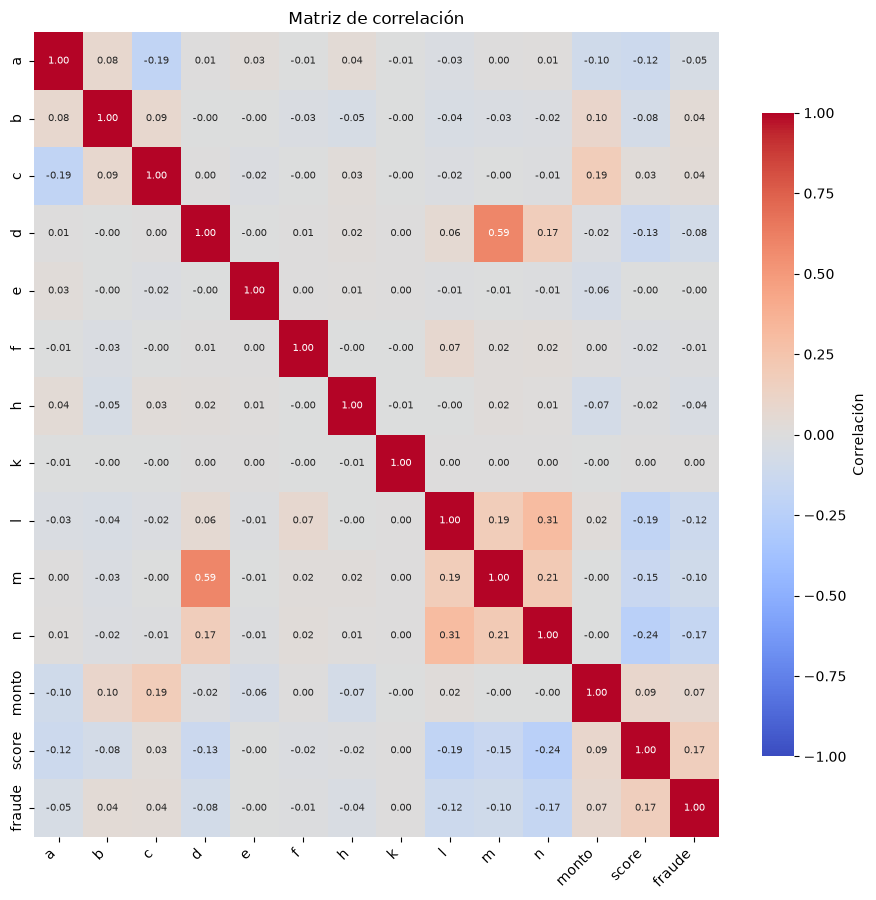

In [27]:
corr_matrix = eda.correlation_matrix()
corr_matrix.to_csv(TABLES_DIR / "02_matriz_correlacion.csv")
eda.plot_correlation_heatmap(
    corr_matrix,
    output_path=FIGURES_DIR / "matriz_correlacion.png",
    close=False,
)
plt.show()

### 2.3 Pares de variables con alta correlación (posible multicolinealidad)

Se buscan pares de features (excluyendo el target) con `|correlación| >= 0.5`.

In [28]:
high_corr = eda.high_correlation_pairs(corr_matrix, threshold=0.5, exclude_cols=[TARGET_COL])
high_corr.to_csv(TABLES_DIR / "03_pares_alta_correlacion.csv", index=False)
high_corr

,variable_1,variable_2,corr
0,d,m,0.5908


**Conclusión:** 
- No se encontraron pares de variables con |correlación| ≥ 0.7
- La correlación más alta observada en la matriz completa es `d`-`m` (~0.59) posible multicolinealidad entre estas features aunque no fuerte.



### 2.4 VIF (Variance Inflation Factor)

Los valores VIF, permite detectar cuando una variable es explicada por una combinación de varias, el cálculo requiere filas sin nulos en las columnas analizadas.
- VIF > 10 indica multicolinealidad severa, 
- VIF entre 5-10 moderada, 
- VIF < 5 baja. 

In [29]:
vif_result = eda.variance_inflation_factors(cols=numeric_cols)
print(f"Filas usadas: {vif_result['n_rows_used']:,} | Filas descartadas por nulos: {vif_result['n_rows_dropped']:,}")
vif_result["vif"].to_csv(TABLES_DIR / "04_vif.csv", index=False)
vif_result["vif"]

Filas usadas: 92,129 | Filas descartadas por nulos: 12,852


,columna,vif,multicolinealidad
0,m,1.61,baja
1,d,1.56,baja
2,n,1.18,baja
3,l,1.16,baja
4,score,1.12,baja
5,c,1.08,baja
6,a,1.07,baja
7,monto,1.07,baja
8,b,1.04,baja
9,f,1.01,baja


**Conclusión (2.4):** 
- Todos los VIF son muy bajos (máximo 1.61 en `m`), muy por debajo del umbral de 5-10 que indicaría multicolinealidad moderada/severa.
- Se puede optar por conservar todas las fetaures sin descartar por multicolinealidad severa o moderada, sin embargo, se puede aplicar alguna técnica que permita eliminar la correlación entre `m` y `d`. 
- El cálculo excluyó 12,852 filas de train, ~12.2%, por tener algún nulo en las variables: `b`/`c`/`d`/`f`/`l`/`m`

### 2.5 Verificación de multicolinealidad con Regresión Logística

El VIF se calcula sobre la matriz de diseño de las features y es independiente del modelo. Como complemento, se ajusta una Regresión Logística sobre las mismas variables numéricas estandarizadas, para observar si la posible redundancia entre `d` y `m` (correlación ~0.59) afecta la estabilidad de los coeficientes o sus errores estándar, un síntoma típico de multicolinealidad que el VIF por sí solo no muestra.


In [30]:

lr_df = df[numeric_cols + [TARGET_COL]].dropna()
X_lr = (lr_df[numeric_cols] - lr_df[numeric_cols].mean()) / lr_df[numeric_cols].std()
X_lr = sm.add_constant(X_lr)
y_lr = lr_df[TARGET_COL]

logit_full = sm.Logit(y_lr, X_lr).fit(disp=0)
cond_number = np.linalg.cond(X_lr.values)
print(f"Filas usadas: {len(lr_df):,} | condition number: {cond_number:.1f}")
logit_full.summary2().tables[1]


Filas usadas: 92,129 | condition number: 2.2


,Coef.,Std.Err.,z,P>|z|,[0.025,0.975]
const,-3.400730,0.021521,-158.020442,0.000000e+00,-3.442910,-3.358550
a,-0.079163,0.013890,-5.699434,1.202059e-08,-0.106386,-0.051940
b,0.167120,0.016540,10.103790,5.314741e-24,0.134701,0.199538
c,0.046694,0.012529,3.726821,1.939103e-04,0.022137,0.071251
d,-0.069242,0.022506,-3.076633,2.093530e-03,-0.113353,-0.025132
e,0.007363,0.012067,0.610178,5.417439e-01,-0.016287,0.031013
f,-0.156951,0.111804,-1.403804,1.603771e-01,-0.376082,0.062181
h,-0.105637,0.016912,-6.246321,4.202318e-10,-0.138784,-0.072491
k,0.031249,0.015593,2.004036,4.506624e-02,0.000687,0.061811
l,-0.329982,0.021133,-15.614844,5.768648e-55,-0.371401,-0.288563


**Lectura del condition number:** valores por debajo de 30 se consideran normales, entre 30-100 sugieren multicolinealidad moderada y por encima de 100, severa (regla usual también aplicada al VIF).

In [31]:
def fit_logit(cols):
    sub = lr_df[cols + [TARGET_COL]].dropna()
    Xs = (sub[cols] - sub[cols].mean()) / sub[cols].std()
    Xs = sm.add_constant(Xs)
    return sm.Logit(sub[TARGET_COL], Xs).fit(disp=0)

logit_sin_d = fit_logit([c for c in numeric_cols if c != "d"])
logit_sin_m = fit_logit([c for c in numeric_cols if c != "m"])

comparacion = pd.DataFrame({
    "coef_full": logit_full.params,
    "se_full": logit_full.bse,
    "coef_sin_d": logit_sin_d.params.reindex(logit_full.params.index),
    "se_sin_d": logit_sin_d.bse.reindex(logit_full.params.index),
    "coef_sin_m": logit_sin_m.params.reindex(logit_full.params.index),
    "se_sin_m": logit_sin_m.bse.reindex(logit_full.params.index),
}).round(4)
comparacion.to_csv(TABLES_DIR / "08_logit_comparacion_multicolinealidad.csv")
comparacion.loc[["d", "m"]]


,coef_full,se_full,coef_sin_d,se_sin_d,coef_sin_m,se_sin_m
d,-0.0692,0.0225,NaN,NaN,-0.1952,0.0181
m,-0.2535,0.0278,-0.3052,0.0227,NaN,NaN


**Conclusión:**
- Todas las variables (excepto `e` y `f`) resultan significativas (p<0.05) en el modelo completo; los signos de `n`, `l` y `score` son consistentes con las correlaciones observadas en 2.1.
- Al remover `m`, el coeficiente de `d` sube de -0.069 a -0.195 (std.err. se mantiene ~0.02), es decir, `d` absorbe parte del efecto de `m` sobre el target, señal coherente con su correlación (~0.59) y el VIF más alto del grupo (1.61/1.56).
- Al remover `d`, el coeficiente de `m` cambia menos (-0.254 → -0.305) y su signo y magnitud se mantienen razonablemente estables.
- No hay cambios de signo ni inflación del error estándar en ningún caso, así que **no se confirma multicolinealidad severa**: `d` y `m` comparten algo de información predictiva (redundancia moderada) pero no distorsionan la estimación de la Regresión Logística lo suficiente como para justificar eliminar alguna de las dos antes de modelar.

## 3. Sesgo (skewness) y outliers en variables numéricas (train)

Se excluyen columnas binarias (no aplica el concepto de sesgo/outlier de la misma forma). 

- Sesgo: "bajo" (|skew|<=0.5), 
- Sesgo: "moderado" (<=1), 
- Sesgo: "alto" (>1).
- Outliers (regla IQR): "bajo" (<=1%), "moderado" (<=5%), "alto" (>5%).

In [32]:
dist_summary = eda.numeric_distribution_summary()
dist_summary.to_csv(TABLES_DIR / "05_sesgo_outliers.csv", index=False)
dist_summary

,columna,media,mediana,std,min,max,skewness,sesgo,n_outliers_iqr,pct_outliers_iqr,outliers
0,a,3.6940,4.0000,0.7622,1.00,4.000000e+00,-2.2917,alto,15661,0.1492,alto
1,c,253923.6542,43433.4350,820638.1277,0.16,1.387874e+07,6.5684,alto,11300,0.1223,alto
2,f,52.6215,8.0000,671.1708,-4.00,1.452740e+05,124.8080,alto,12094,0.1152,alto
3,monto,44.3955,21.3100,92.2580,0.02,3.696350e+03,9.5658,alto,10236,0.0975,alto
4,b,0.7273,0.7537,0.1332,0.00,1.000000e+00,-1.6140,alto,6134,0.0664,alto
5,e,0.2119,0.0956,1.2015,0.00,2.850857e+02,142.2057,alto,5325,0.0507,alto
6,h,14.2043,9.0000,14.0890,0.00,5.800000e+01,1.1908,alto,3317,0.0316,moderado
7,m,299.4445,193.0000,319.7749,0.00,2.215000e+03,1.3654,alto,3092,0.0295,moderado
8,l,2305.8357,1938.0000,1710.6958,0.00,7.530000e+03,0.6787,moderado,246,0.0023,bajo
9,d,21.5063,14.0000,19.9685,0.00,5.000000e+01,0.4420,bajo,0,0.0000,bajo


In [33]:
print("Top 5 variables con mayor sesgo:")
print(dist_summary.reindex(dist_summary["skewness"].abs().sort_values(ascending=False).index)[["columna", "skewness", "sesgo"]].head(5).to_string(index=False))

print("\nTop 5 variables con mayor % de outliers (IQR):")
print(dist_summary[["columna", "pct_outliers_iqr", "outliers"]].head(5).to_string(index=False))

Top 5 variables con mayor sesgo:
columna  skewness sesgo
      e  142.2057  alto
      f  124.8080  alto
  monto    9.5658  alto
      c    6.5684  alto
      a   -2.2917  alto

Top 5 variables con mayor % de outliers (IQR):
columna  pct_outliers_iqr outliers
      a            0.1492     alto
      c            0.1223     alto
      f            0.1152     alto
  monto            0.0975     alto
      b            0.0664     alto


**Conclusión:** 
- las variables con mayor sesgo son `e` y `f` (skewness > 100, por valores extremos muy raros), seguidas de `monto` y `c`, todas candidatas a una transformación logarítmica si se usan en un modelo sensible a la escala (p. ej. regresión logística). 
- En outliers (regla IQR), `a`, `c`, `f`, `monto` y `b` concentran entre 6.6% y 14.9% de valores atípicos, confirmado visualmente por los histogramas y boxplots (colas muy largas). 
- `d`, `k` y `score` no presentan sesgo ni outliers relevantes. 

## 3.1 Distribución numérica diferenciada por target (`fraude`)

Los histogramas y boxplots muestran la forma general de cada variable, pero no si esa forma cambia entre transacciones legítimas y fraudulentas. Aquí se separan ambas clases: histogramas superpuestos (normalizados a densidad, ya que `fraude=1` es ~5% de las filas) y boxplots lado a lado por clase.

In [34]:
hist_cols = ["a","c","f","monto","b","e","h","m","l","d","k","score"]

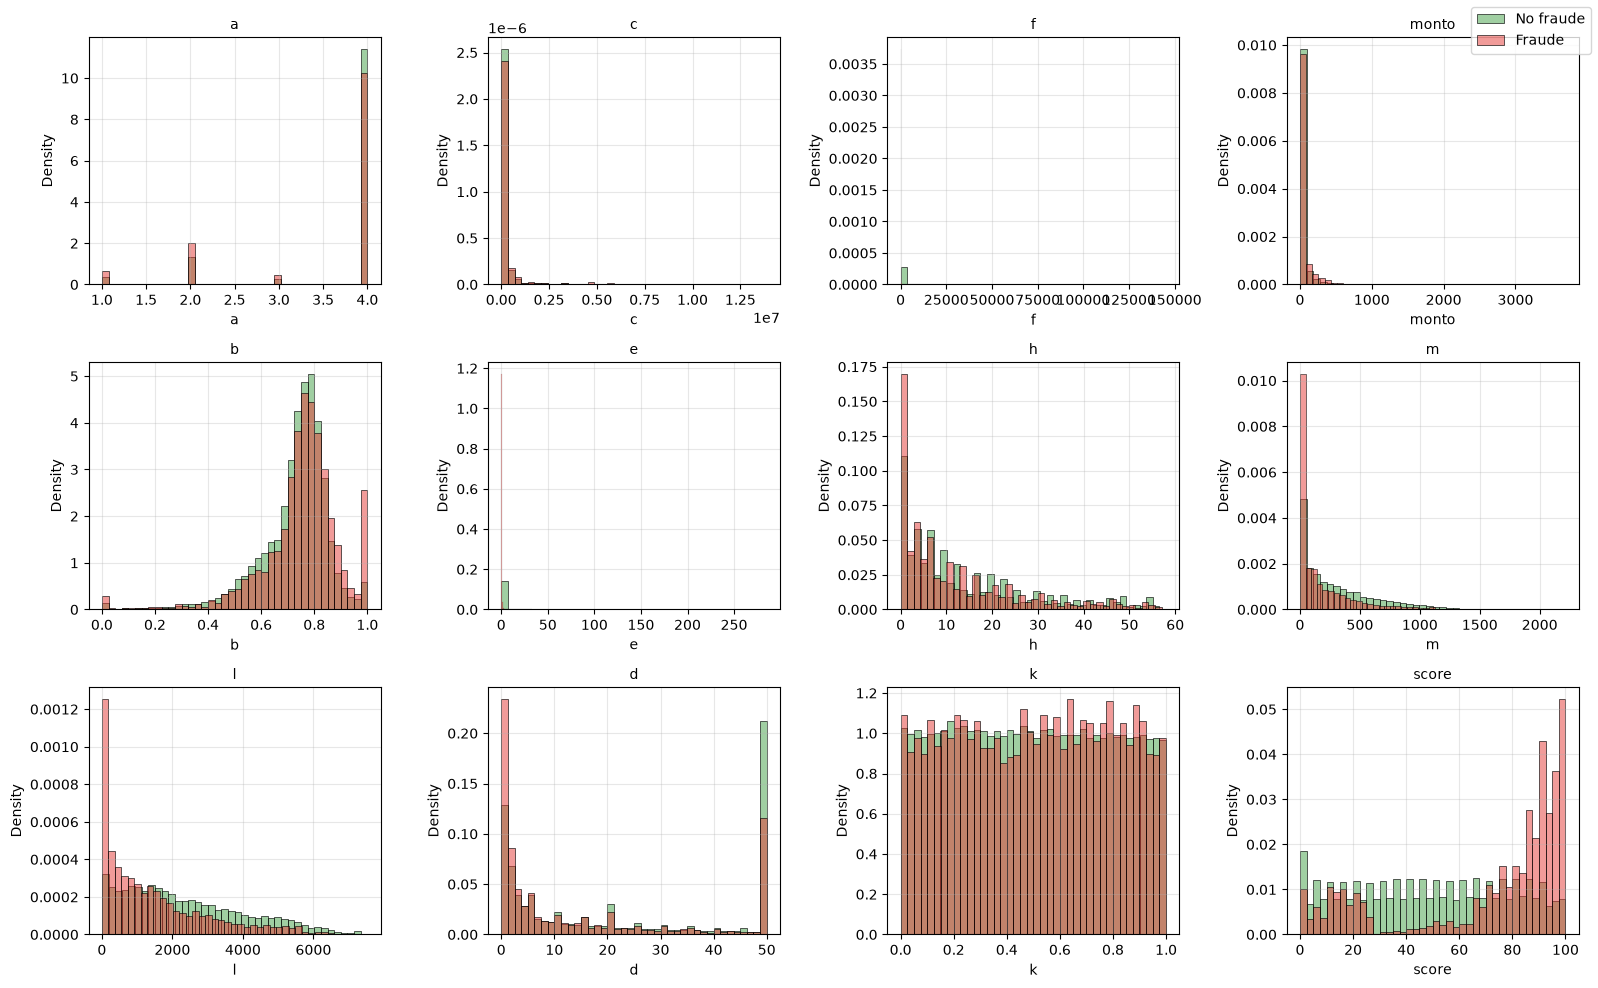

In [35]:
plot_numeric_grid_by_target(
    df, hist_cols, TARGET_COL, kind="hist",
    output_path=FIGURES_DIR / "histogramas_numericas_por_target.png",
    close=False,
)
plt.show()

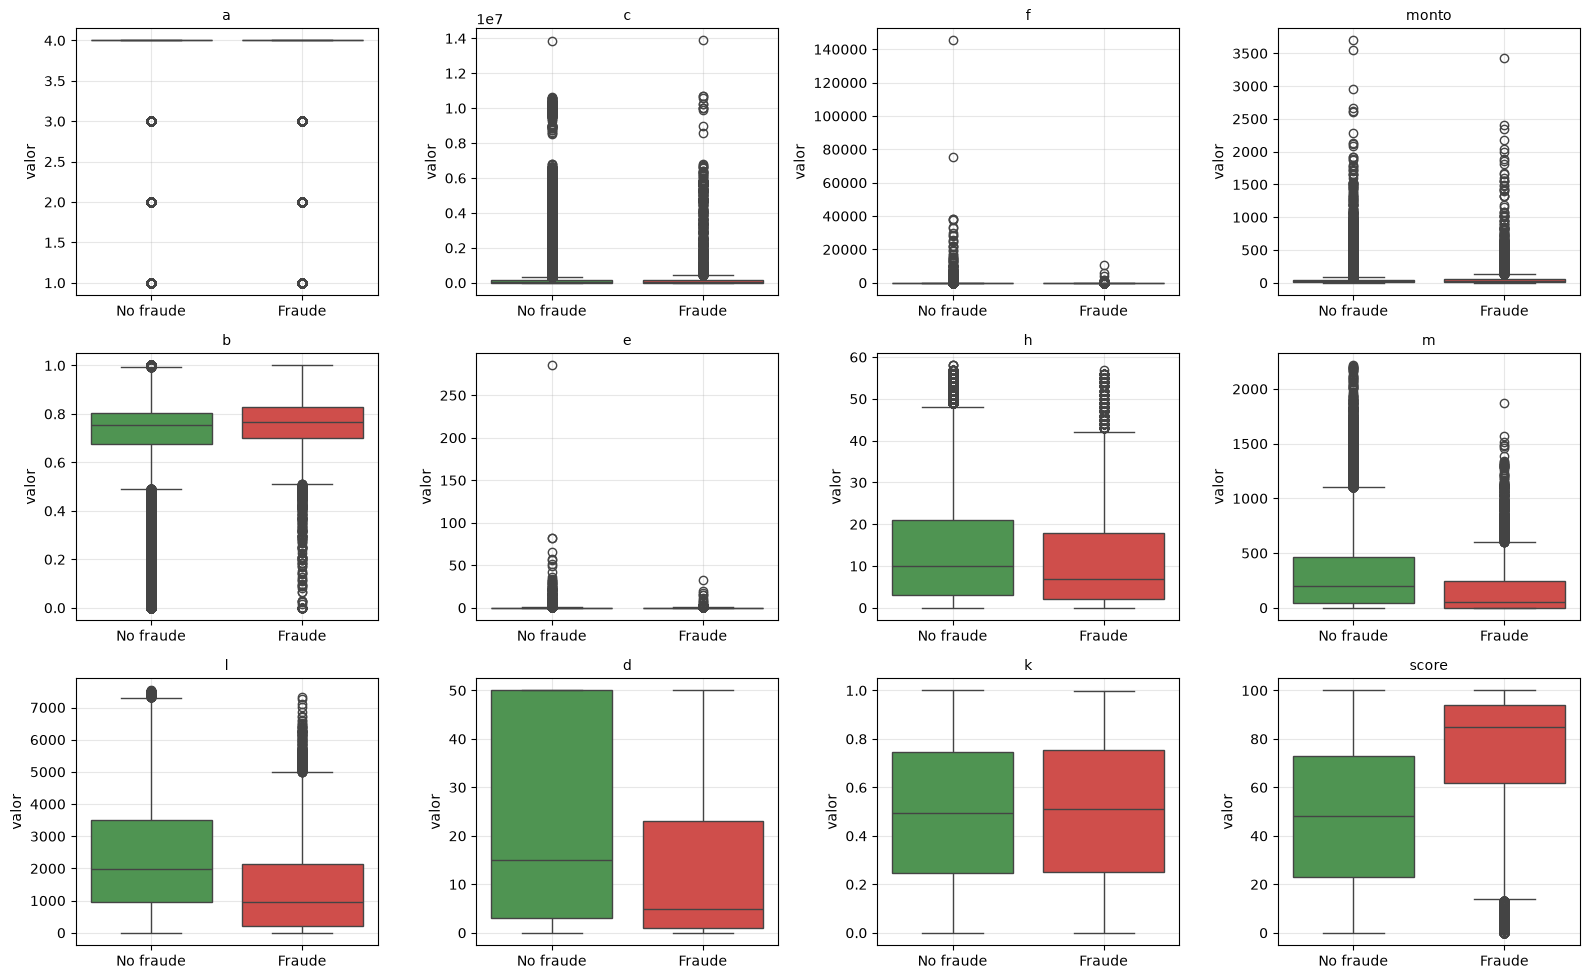

In [36]:
plot_numeric_grid_by_target(
    df, hist_cols, TARGET_COL, kind="box",
    output_path=FIGURES_DIR / "boxplots_numericas_por_target.png",
    close=False,
)
plt.show()

**Conclusión:**
- `score` muestra la separación más clara entre clases: mediana de 85 en fraude vs. 48 en no fraude (+77%), consistente con ser la variable con mayor correlación positiva con el target (2.1).
- `m`, `d`, `l`, `e` y `f` tienden a ser notablemente **menores** en transacciones fraudulentas (medianas entre 53% y 89% más bajas), también consistente con sus correlaciones negativas en 2.1.
- `a`, `b` no muestran diferencias visibles entre clases, coherente con su correlación casi nula con el target.
- `k` es el ID unico por fila puede descartarse su analisis visual

## 4. Asociación de variables categoricas con el target

Para este análisis se consideran categóricas las columnas `a, g, j, n, o, p` (incluye `a` y `n`, que aunque son de tipo numérico en el CSV, representan códigos/categorías discretas y no cantidades continuas).

### 4.1 Asociación con el target (Cramér's V + chi-cuadrado)

Cramér's V se interpreta como: <0.1 despreciable, 0.1-0.3 débil, 0.3-0.5 moderada, >0.5 fuerte.

In [37]:
CATEGORICAL_COLS = ["a", "g", "j", "n", "o", "p"]

assoc = eda.categorical_target_association(TARGET_COL, cols=CATEGORICAL_COLS)
assoc.to_csv(TABLES_DIR / "06_asociacion_categoricas_target.csv", index=False)
assoc

,columna,n_categorias,cramers_v,p_value,asociacion_con_target
0,j,7558,0.2995,4.175814e-45,débil
1,o,3,0.2936,0.000000e+00,débil
2,n,2,0.1711,0.000000e+00,débil
3,p,2,0.1107,1.723001e-281,débil
4,g,45,0.0568,3.167772e-47,despreciable
5,a,4,0.0560,6.009785e-71,despreciable


**Conclusión:** 
- Con las 6 categóricas correctamente identificadas (`a, g, j, n, o, p`), `j` (categoría/entidad) y `o` siguen siendo las más asociadas al fraude (Cramér's V ≈ 0.30 y 0.29, "débil" según el criterio convencional). 
- `n` aparece ahora en el análisis con un Cramér's V de 0.17 ("débil" también, pero notablemente más alto que `p` y `g`), consistente con la correlación de -0.17 vista en 2.1, ya que `n` es binaria.
- `a` resulta prácticamente irrelevante (0.056, despreciable), similar a `g`. El Cramér's V de `j` puede estar subestimado por su altísima cardinalidad (7,558 categorías).

### 4.2 Tasa de fraude y lift por categoría

`lift` = tasa de fraude de la categoría / tasa global de train. Solo se muestran categorías con al menos 30 observaciones esto para evitar ruido de categorias pequeñas, se muestran solo las primeras 4

In [38]:
for col in CATEGORICAL_COLS:
    
    rate_table = eda.category_fraud_rate(TARGET_COL, col, min_support=30)
    rate_table.to_csv(TABLES_DIR / f"07_tasa_fraude_{col}.csv", index=False)
    print(f"--- Columna: {col} (categorías con soporte >= 30: {len(rate_table)}) ---")
    print("Top 5 con mayor tasa de fraude:")
    display(rate_table.head(5))
    print("Top 5 con menor tasa de fraude:")
    display(rate_table.tail(5))

--- Columna: a (categorías con soporte >= 30: 4) ---
Top 5 con mayor tasa de fraude:


,a,n_total,n_positivos,tasa,lift
0,3,2085,195,0.0935,1.80
1,1,2885,258,0.0894,1.72
2,2,10691,811,0.0759,1.46
3,4,89320,4178,0.0468,0.90


Top 5 con menor tasa de fraude:


,a,n_total,n_positivos,tasa,lift
0,3,2085,195,0.0935,1.80
1,1,2885,258,0.0894,1.72
2,2,10691,811,0.0759,1.46
3,4,89320,4178,0.0468,0.90


--- Columna: g (categorías con soporte >= 30: 10) ---
Top 5 con mayor tasa de fraude:


...

,o,n_total,n_positivos,tasa,lift
0,N,11907,2718,0.2283,4.40
1,Y,17027,1108,0.0651,1.26
2,(nulo),76047,1616,0.0213,0.41


--- Columna: p (categorías con soporte >= 30: 2) ---
Top 5 con mayor tasa de fraude:


,p,n_total,n_positivos,tasa,lift
0,N,46551,3693,0.0793,1.53
1,Y,58430,1749,0.0299,0.58


Top 5 con menor tasa de fraude:


,p,n_total,n_positivos,tasa,lift
0,N,46551,3693,0.0793,1.53
1,Y,58430,1749,0.0299,0.58


**Conclusión :** 
- A nivel de categoría individual aparecen señales fuertes y con soporte suficiente para ser útiles como feature:
- **`n`**: cuando `n=0` la tasa de fraude es 16.8%, y cuando `n=1` cae a 3.95%. Es la segunda señal binaria más fuerte después de `o`, y coincide con ser la variable numérica más correlacionada con el target.
- **`o`**: cuando `o="N"` la tasa de fraude es 22.8%; cuando es nulo, cae a 2.1%. Sigue siendo la variable más discriminante del dataset.
- **`j`**: varias categorías concentran tasas de fraude muy altas con soporte razonable (66.7% de fraude, n=36) y (60.9%, n=69), mientras muchas otras categorías tienen 0% de fraude. Aunque el Cramér's V global de `j` es modesto, hay un subconjunto de categorías con señal muy fuerte, potencialmente más útil como feature binaria ("categoría de alto riesgo") que como variable categórica completa.
- **`a`**: variación baja pero monótona entre sus 4 niveles, señal débil pero no completamente nula.
- **`p`** y **`g`** muestran variación moderada, consistente con su Cramér's V bajo.

En conjunto, `o` y `n` (ambas binarias) junto con ciertas categorías específicas de `j` son las señales categóricas más prometedoras para un modelo de detección de fraude; `a` y `g` aportan poco por sí solas.